<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/02_Level_1_Parametric_Spectral_Uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Level 1: Parametric Spectral Uncertainty

Level 1 relaxes the assumption that the endmember spectra are known exactly.

Each component is described by a two-Gaussian spectral model with five parameters:

$$\theta_k = (r,\mu_1,\sigma_1,\mu_2,\sigma_2)$$

The parameter vector has a prior mean and prior standard deviation. The endmember parameters are **global**: one spectrum for each component is shared by all measurement locations.

The model jointly infers spectral parameters and local concentrations/fractions.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


In [2]:
data = pu.generate_example(
    n_locations=50,
    n_channels=120,
    n_library=80,
    spectral_uncertainty=1.0,
    seed=42,
)

print("Level 1 prior parameter means:")
print(data.theta_mean)
print()
print("Level 1 prior parameter SD:")
print(data.theta_sigma)

Level 1 prior parameter means:
[[0.72 1.5  0.22 6.1  0.65]
 [0.52 2.77 0.32 8.2  0.28]
 [0.64 4.62 0.72 9.62 0.42]
 [0.34 1.95 0.6  7.12 0.48]]

Level 1 prior parameter SD:
[[0.08 0.15 0.08 0.15 0.08]
 [0.08 0.15 0.08 0.15 0.08]
 [0.08 0.15 0.08 0.15 0.08]
 [0.08 0.15 0.08 0.15 0.08]]


## Fit Level 1

The same data object is used as in Level 0. Only the spectral knowledge supplied to inference changes.

In [3]:
result1 = pu.fit(
    data,
    level=1,
    n_draws=800,
    seed=101,
    max_nfev=250,
)
print(result1.metrics)

{'reconstruction_rmse': 0.010250475712915607, 'mean_concentration_sd': 0.005922467413528805, 'mean_spectral_sd': 0.0009278327579404111, 'optimizer_cost': 3051.037300497916, 'optimizer_nfev': 62, 'concentration_rmse': 0.0072313930998051034, 'spectral_rmse': 0.002653486010896472}


## Posterior concentrations and endmembers

Level 1 now returns nonzero uncertainty for both the fractions and the endmember spectra.

Mean posterior concentration SD: 0.005922467413528805
Mean posterior spectral SD: 0.0009278327579404111


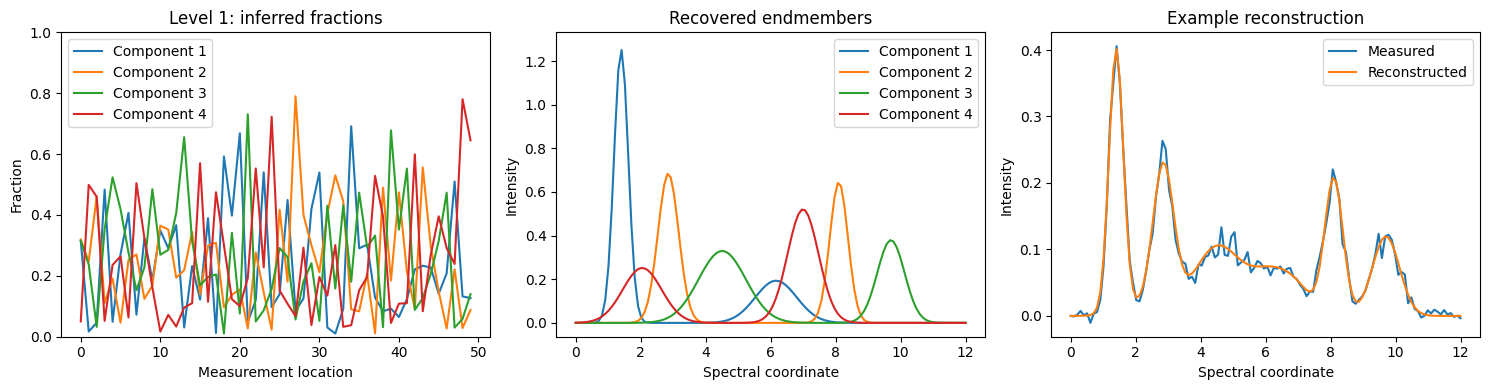

In [4]:
pu.plot_result(data, result1);

print("Mean posterior concentration SD:", result1.W_sd.mean())
print("Mean posterior spectral SD:", result1.S_sd.mean())

## Compare with the exact-spectrum reference

Running Level 0 on the same physical dataset provides a useful reference. Any difference between Level 0 and Level 1 comes from relaxing spectral knowledge, not from changing the observations.

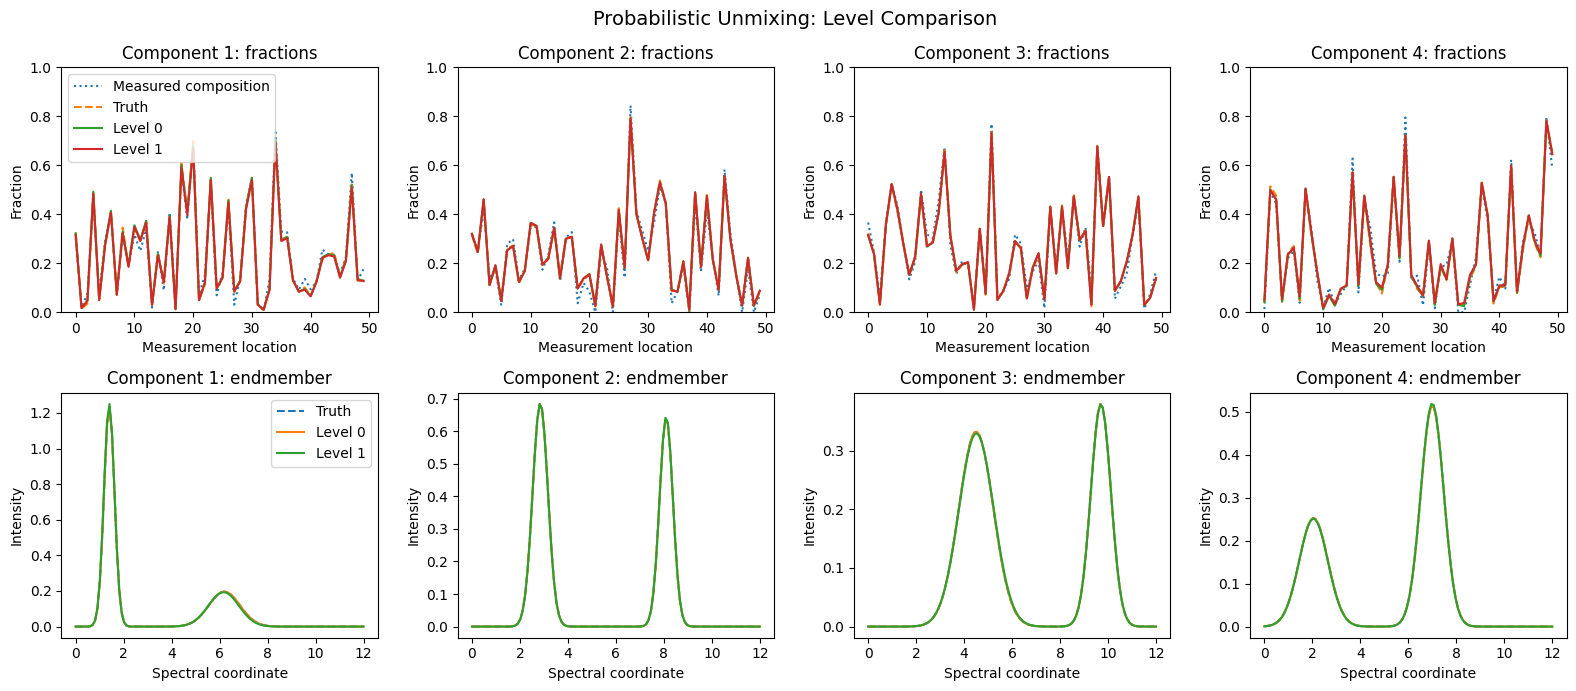

In [5]:
result0 = pu.fit(
    data,
    level=0,
    n_draws=800,
    seed=100,
)

pu.plot_level_comparison(
    data,
    result0,
    result1,
);

**Takeaway:** Level 1 lets spectral uncertainty and concentration uncertainty trade against one another. Strong spectral information can help constrain fractions, and strong concentration information can help constrain spectral parameters.